Saving Crop_recommendation.xlsx to Crop_recommendation (1).xlsx
DATA LOADED
Shape: (2200, 8)

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Missing values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

First 5 rows:
     N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

DESCRIPTIVE STATISTICS
              count        mean        std        min        25%        50%  \
N            2200.0   50.551818  36.917334   0.000000  21.000000  37.000000   
P            2200.0   53.362727  32.985883   5.000000  28.000000  

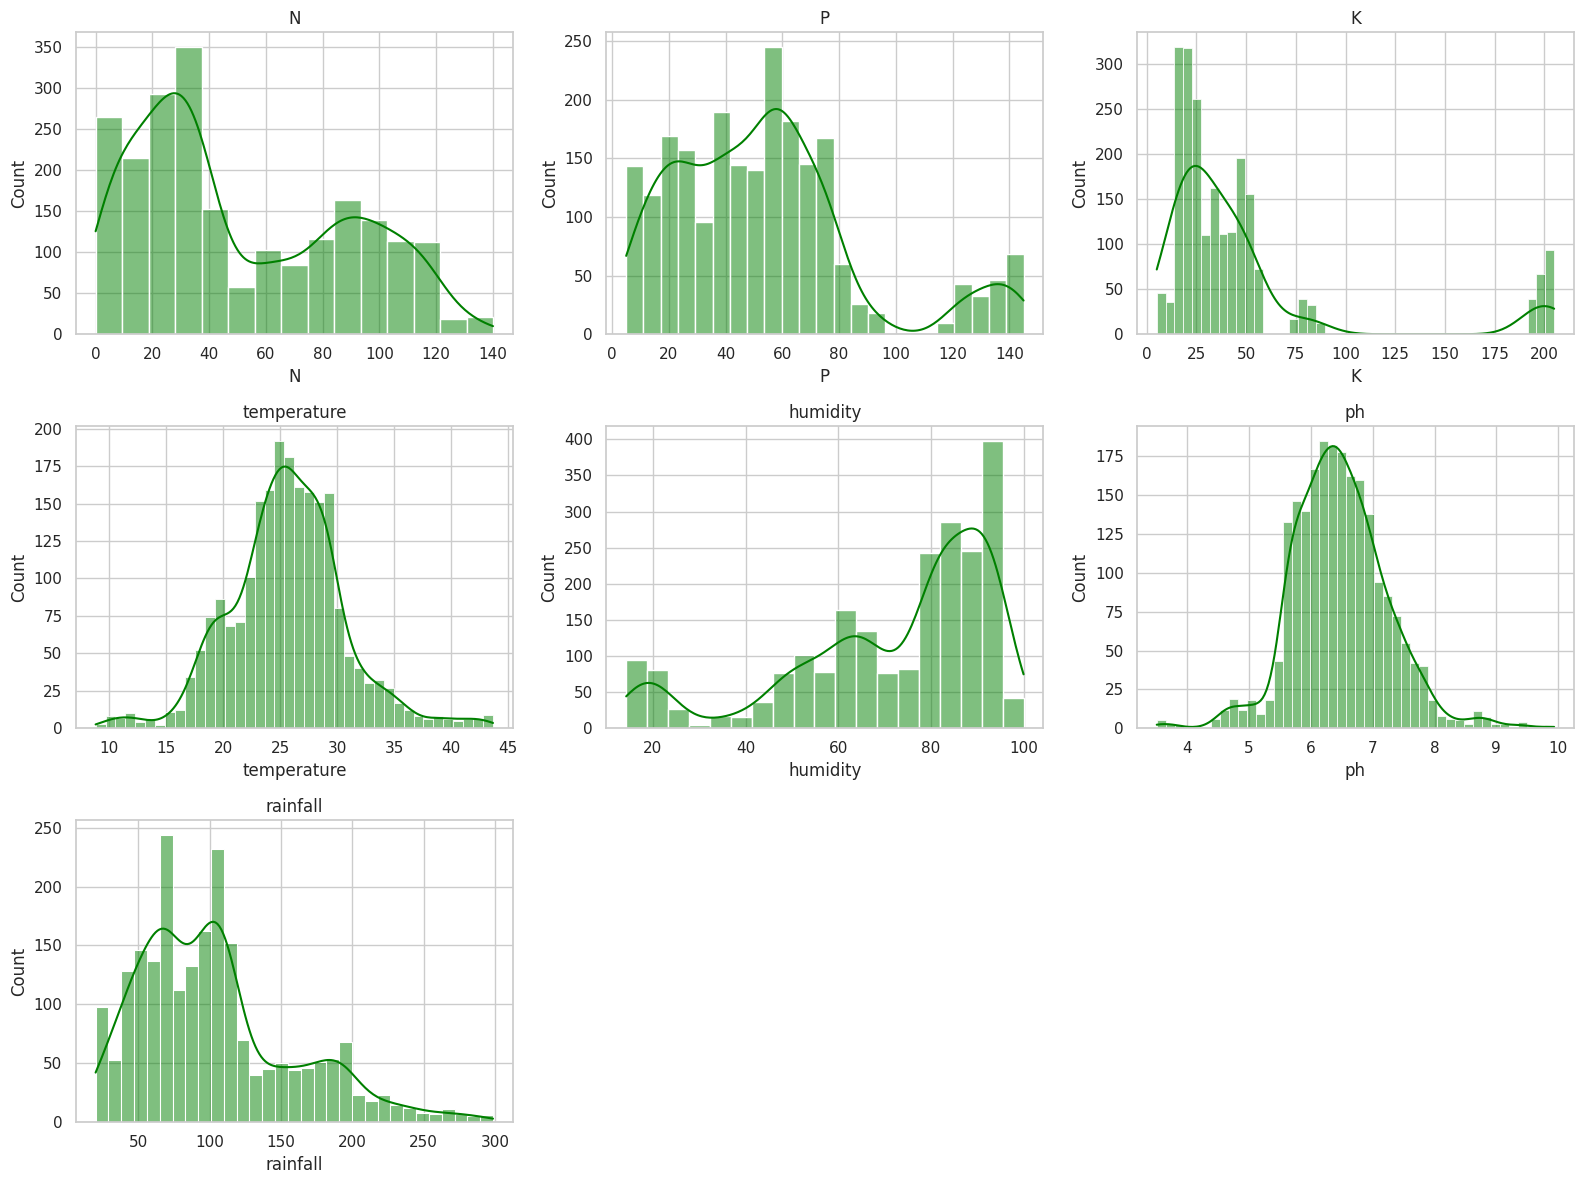

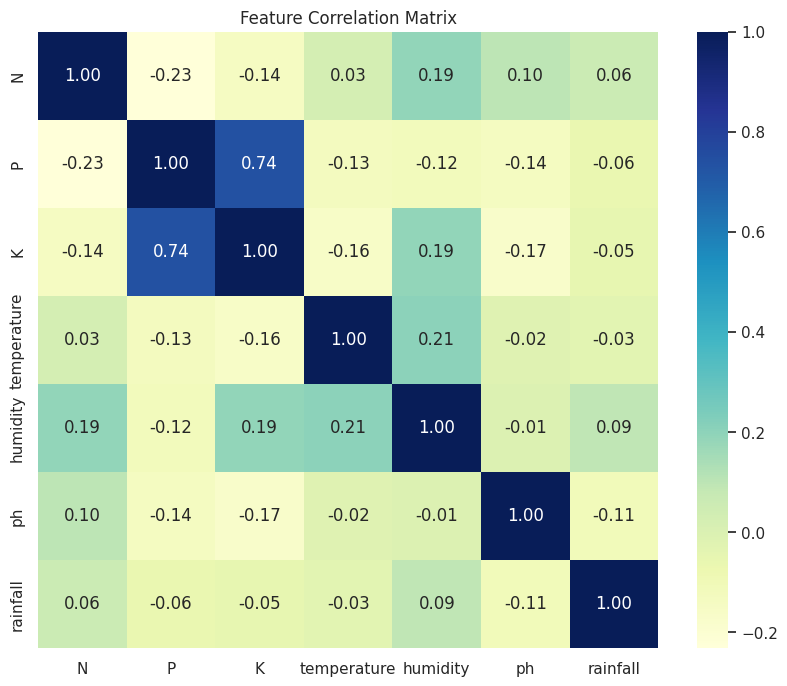


RANDOM FOREST CLASSIFICATION
Accuracy: 0.9926

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        11
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        19
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00         9
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      0.95      0.95        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        15
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      ora

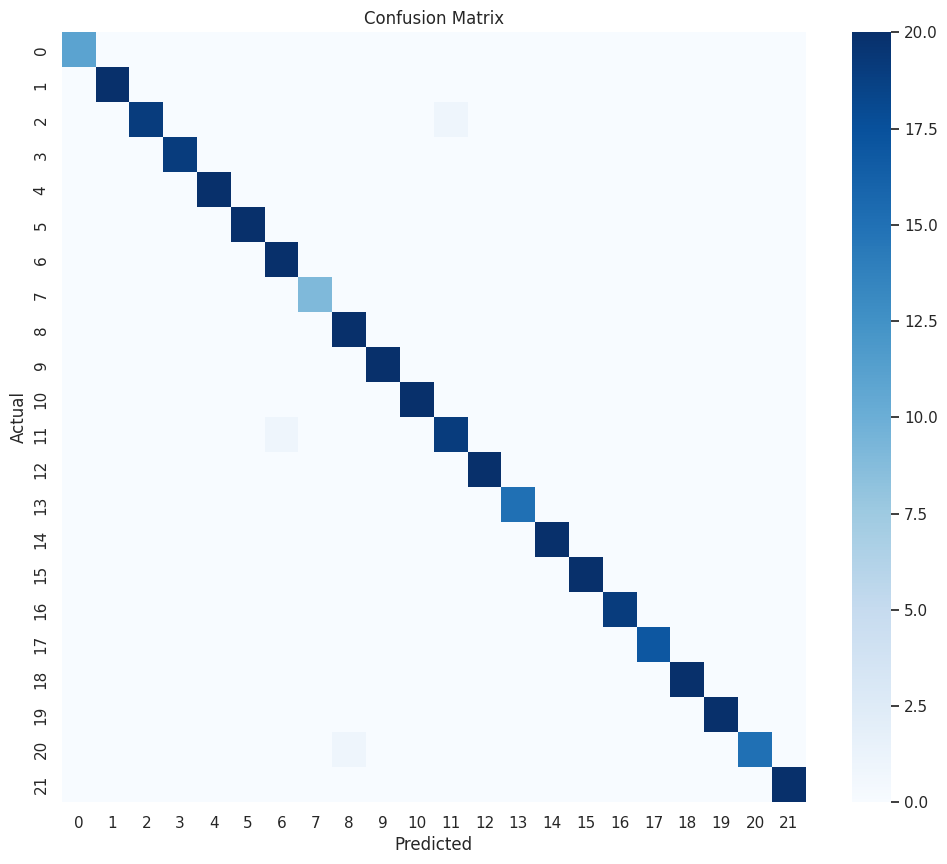


Feature Importance:
        Feature  Importance
6     rainfall    0.223900
4     humidity    0.222288
2            K    0.163693
1            P    0.142429
0            N    0.113956
3  temperature    0.074392
5           ph    0.059343


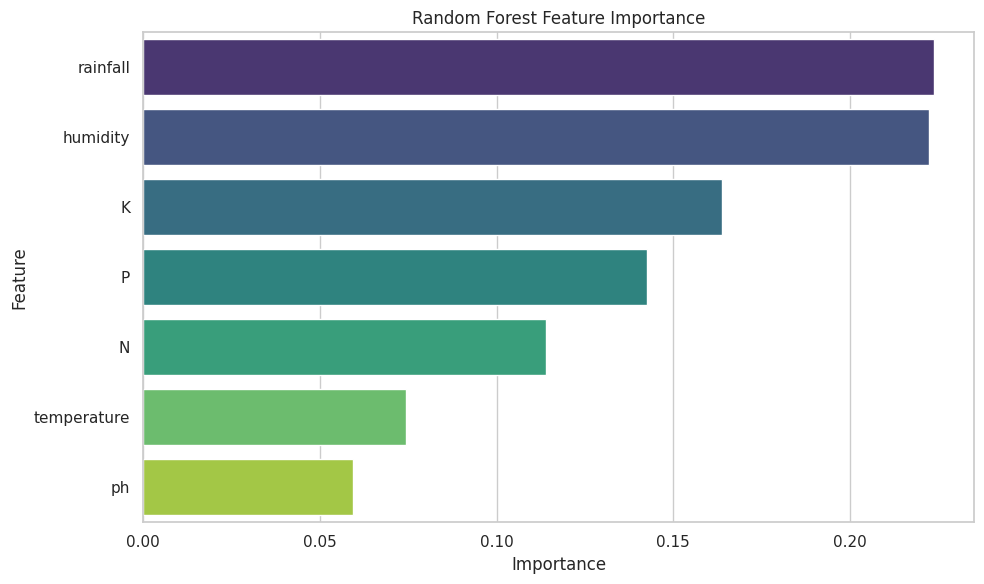


CROSS VALIDATION
Scores: [0.9975 0.9901 0.9951 0.9926 0.9901]
Mean Accuracy: 0.9931
Std Dev: 0.0029

KMEANS CLUSTERING
Cluster counts:
 0    408
1    305
2    102
3    224
4    284
5    520
6    186
Name: count, dtype: int64
Silhouette Score: 0.3178

✔ PROJECT COMPLETED — CROP RECOMMENDATION SYSTEM READY


In [ ]:
# =============================================================
# CROP RECOMMENDATION IN DATA MINING SYSTEM
# Google Colab Ready
# Data mining (frequency, stats)
# Statistical analysis (Z-score, empirical rule)
# Data cleaning
# Visualization (EDA)
# Supervised learning (Random Forest)
# Model evaluation (accuracy, confusion matrix)
# Cross-validation
# Feature importance (interpretability)
# Unsupervised learning (K-Means clustering)
# =============================================================

!pip -q install openpyxl

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

from google.colab import files, drive

# ─────────────────────────────
# FILE INPUT OPTION 1: UPLOAD FROM YOUR COMPUTER
# ─────────────────────────────
uploaded = files.upload()
file_name = next(iter(uploaded))

# ─────────────────────────────

# ─────────────────────────────
FEATURES = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
TARGET = 'label'
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_BINS = 10

# ─────────────────────────────
# LOAD DATA
# ─────────────────────────────
df = pd.read_excel("/content/Crop_recommendation.xlsx")

print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst 5 rows:\n", df.head())

# ─────────────────────────────
# CLEANUP
# ─────────────────────────────
df.columns = [c.strip() for c in df.columns]
df = df.drop_duplicates().reset_index(drop=True)

# ─────────────────────────────
# DESCRIPTIVE STATISTICS
# ─────────────────────────────
print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

desc = df[FEATURES].describe().T
desc["median"] = df[FEATURES].median()
desc["mode"] = df[FEATURES].mode().iloc[0]
print(desc)

# ─────────────────────────────
# GROUPED FREQUENCY TABLES
# ─────────────────────────────
print("\n" + "=" * 60)
print("GROUPED FREQUENCY TABLES")
print("=" * 60)

for col in FEATURES:
    mn, mx = df[col].min(), df[col].max()
    edges = np.linspace(mn, mx, N_BINS + 1)
    edges[-1] += 1e-9
    labels = [f"{edges[i]:.2f}-{edges[i+1]:.2f}" for i in range(N_BINS)]
    binned = pd.cut(df[col], bins=edges, labels=labels, include_lowest=True)
    freq = binned.value_counts().reindex(labels).fillna(0)

    print(f"\n--- {col} ---")
    print(pd.DataFrame({"Interval": labels, "Frequency": freq.values}))

# ─────────────────────────────
# Z-SCORE AND EMPIRICAL RULE
# ─────────────────────────────
print("\n" + "=" * 60)
print("Z-SCORE AND EMPIRICAL RULE")
print("=" * 60)

z = df[FEATURES].apply(stats.zscore)
print("\nZ-score head:\n", z.head())

for col in FEATURES:
    mu = df[col].mean()
    sigma = df[col].std()
    p1 = ((df[col] >= mu - sigma) & (df[col] <= mu + sigma)).mean() * 100
    p2 = ((df[col] >= mu - 2 * sigma) & (df[col] <= mu + 2 * sigma)).mean() * 100
    p3 = ((df[col] >= mu - 3 * sigma) & (df[col] <= mu + 3 * sigma)).mean() * 100
    print(f"{col}: ±1σ={p1:.2f}% | ±2σ={p2:.2f}% | ±3σ={p3:.2f}%")

# ─────────────────────────────
# OPTIONAL OUTLIER REMOVAL
# ─────────────────────────────
z_abs = np.abs(stats.zscore(df[FEATURES]))
df_clean = df[(z_abs < 3).all(axis=1)].reset_index(drop=True)

print("\n" + "=" * 60)
print("OUTLIER REMOVAL")
print("=" * 60)
print("Before:", len(df))
print("After:", len(df_clean))
print("Removed:", len(df) - len(df_clean))

# ─────────────────────────────
# VISUALIZATION
# ─────────────────────────────
sns.set(style="whitegrid")

plt.figure(figsize=(16, 12))
for i, col in enumerate(FEATURES, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color="green")
    plt.title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df[FEATURES].corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

# ─────────────────────────────
# RANDOM FOREST CLASSIFICATION
# ─────────────────────────────
print("\n" + "=" * 60)
print("RANDOM FOREST CLASSIFICATION")
print("=" * 60)

X = df_clean[FEATURES]
y = df_clean[TARGET]

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_enc
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)

pred = model.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, pred, target_names=le.classes_))

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ─────────────────────────────
# FEATURE IMPORTANCE
# ─────────────────────────────
importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance:\n", importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x="Importance", y="Feature", palette="viridis")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

# ─────────────────────────────
# CROSS VALIDATION
# ─────────────────────────────
X_all_scaled = scaler.fit_transform(df_clean[FEATURES])
y_all = le.fit_transform(df_clean[TARGET])

cv_model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
scores = cross_val_score(cv_model, X_all_scaled, y_all, cv=5, scoring="accuracy")

print("\n" + "=" * 60)
print("CROSS VALIDATION")
print("=" * 60)
print("Scores:", np.round(scores, 4))
print("Mean Accuracy:", round(scores.mean(), 4))
print("Std Dev:", round(scores.std(), 4))

# ─────────────────────────────
# KMEANS CLUSTERING
# ─────────────────────────────
print("\n" + "=" * 60)
print("KMEANS CLUSTERING")
print("=" * 60)

kmeans = KMeans(n_clusters=7, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_all_scaled)

print("Cluster counts:\n", pd.Series(clusters).value_counts().sort_index())
print("Silhouette Score:", round(silhouette_score(X_all_scaled, clusters), 4))

df_clean["cluster"] = clusters

print("\n✔ PROJECT COMPLETED — CROP RECOMMENDATION SYSTEM READY")